In [ ]:
# --- CONFIGURATION ---
PRODUCE_PDF_REPORT = True


# Disney Exploration

In [1]:
import os
import sys
from pathlib import Path
import importlib

import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from stampli.paths import get_enriched_path
from stampli.util.runtime import bootstrap_spark_env

bootstrap_spark_env()
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, lower

import stampli.util.display
importlib.reload(stampli.util.display)
from stampli.util.display import display_scrollable_dataframe
from stampli.paths import get_enriched_path

from stampli.disney_viz import (
    visualize_theme_sentiment,
    visualize_low_rating_drivers,
    visualize_seasonality,
    visualize_country_sentiment,
    visualize_staff_impact,
    visualize_crowd_impact,
    get_evidence_quotes,
    generate_cx_playbook
)


In [2]:
# Add src to sys.path so we can import stampli package
notebook_dir = Path("__file__").parent.resolve() if "__file__" in locals() else Path(".").resolve()

# Assuming structure: project_root/src/stampli/notebook.ipynb
# If running from notebook dir:
if notebook_dir.name == "stampli" and notebook_dir.parent.name == "src":
    PROJECT_ROOT = notebook_dir.parents[1]
else:
    # Fallback: assume CWD is project root or we are somewhere else. 
    # Let's try to find 'src' upwards.
    PROJECT_ROOT = Path(".").resolve()

src_path = str(PROJECT_ROOT / "src")
if src_path not in sys.path:
    sys.path.append(src_path)
print(f"Added {src_path} to sys.path")
print(f"Project Root: {PROJECT_ROOT}")

ENRICHED_PATH = str(get_enriched_path())
# Redefine output paths relative to PROJECT_ROOT
OUTPUT_DIR = PROJECT_ROOT / "output" / "disney_exploration"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output Directory: {OUTPUT_DIR}")


Added /home/gideon/tmp/stampli/src to sys.path


In [3]:

bootstrap_spark_env()

spark = (SparkSession.builder
    .appName("DisneyExploration")
    .config("spark.executor.memory", "16g")
    .config("spark.driver.memory", "16g")
    .getOrCreate())

spark.sparkContext.setLogLevel("ERROR")
print("Spark Session Created (16GB)")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/19 14:20:22 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark Session Created (16GB)


In [4]:
# read enriched data
spd_disney = (spark.read
    .parquet(ENRICHED_PATH)
)
disney_count = spd_disney.count()
print(f"Total Enriched Rows: {disney_count}")

Total Enriched Rows: 42656


In [5]:
# Create Pandas DataFrame (pd_disney)

print("Converting to Pandas (pd_disney)...")
pd_disney = spd_disney.toPandas()

print(f"Pandas DF Shape: {pd_disney.shape}")
display_scrollable_dataframe(pd_disney)

Converting to Pandas (pd_disney)...


Pandas DF Shape: (42656, 15)


In [6]:
pd_disney.columns

Index(['Branch', 'Rating', 'sentiment_score', 'sentiment_label',
       'is_complaint', 'crowd_level', 'staff_sentiment', 'price_sensitivity',
       'family_sentiment', 'Reviewer_Location', 'Season', 'topics',
       'Review_Text', 'Year_Month', 'review_uid'],
      dtype='object')

## Visual Insights

### 1️⃣ Theme × Sentiment Heatmap
Using robust metrics (Median, Share Negative) gated by N>=30 reviews.


=== Insight 1: Theme x Sentiment Heatmaps ===


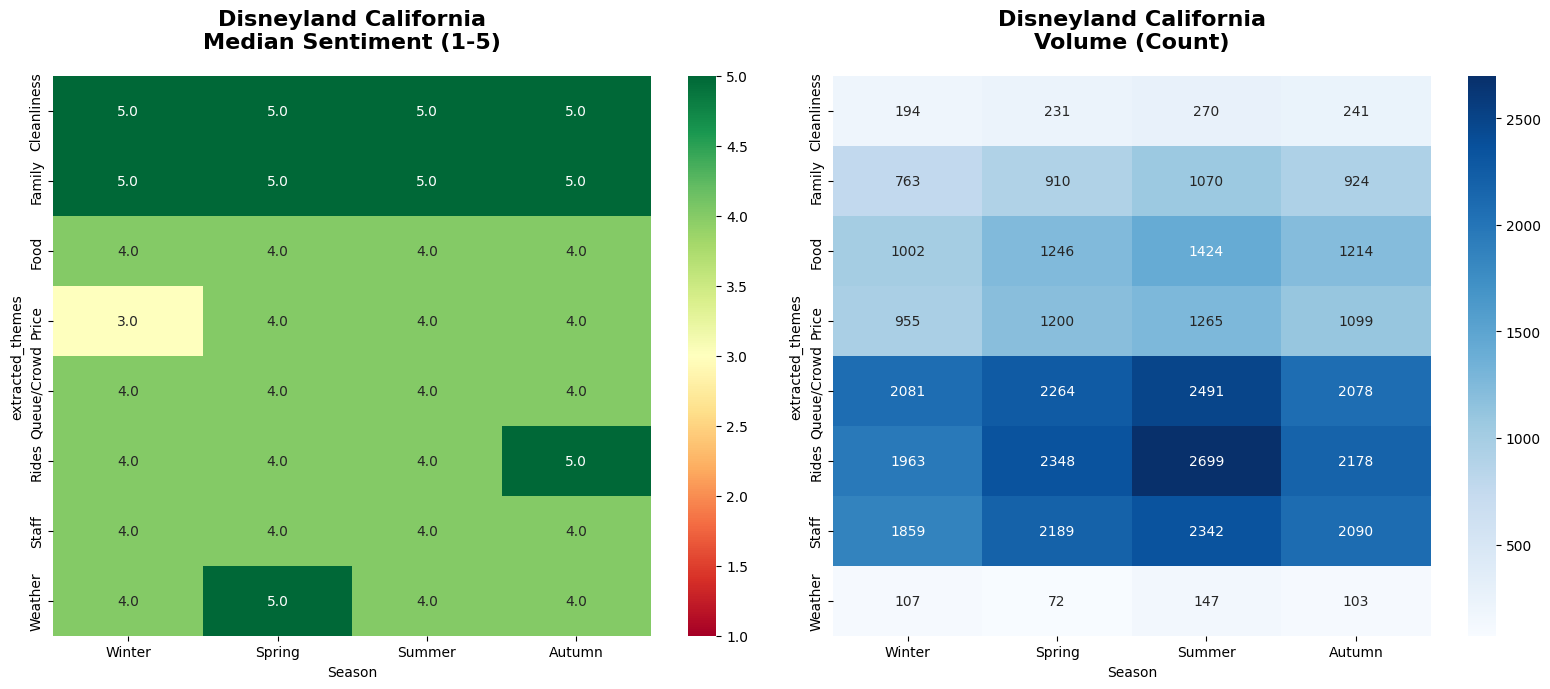

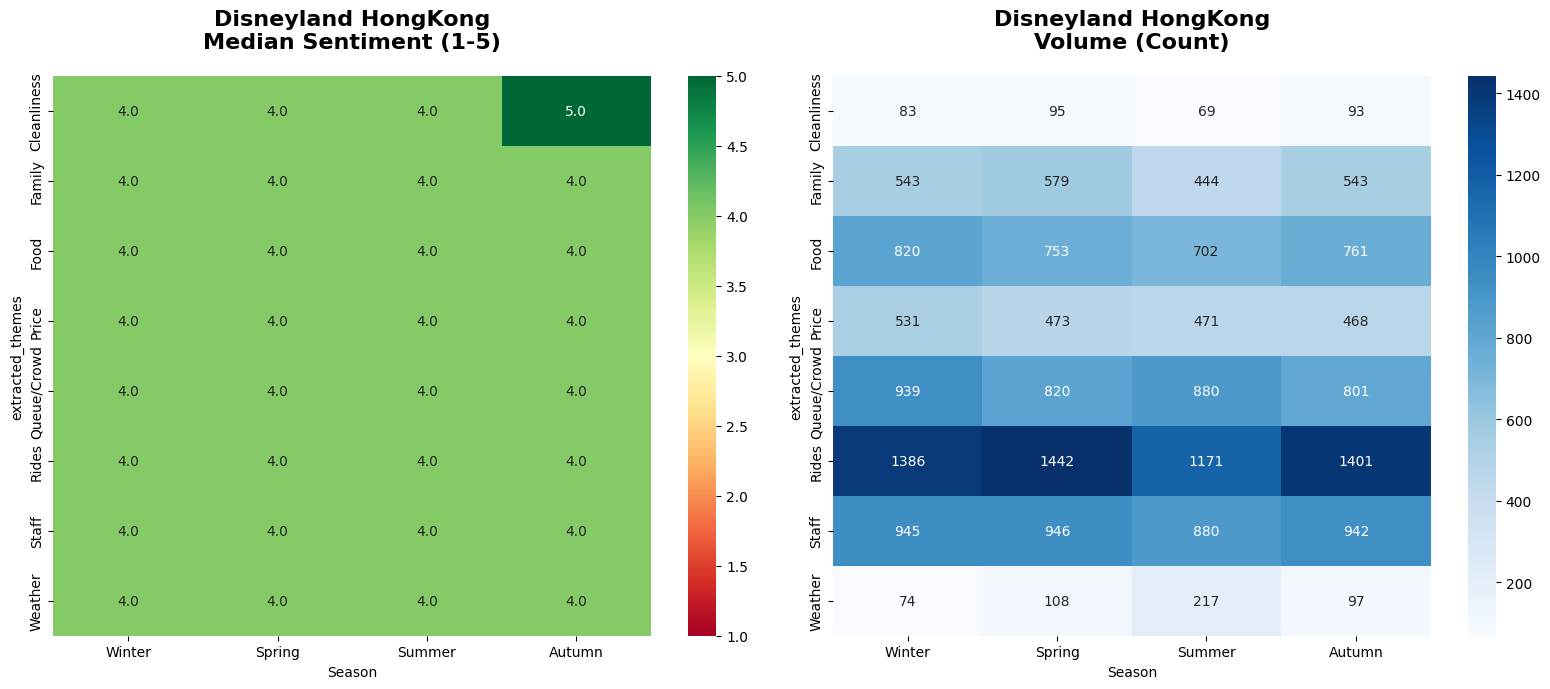

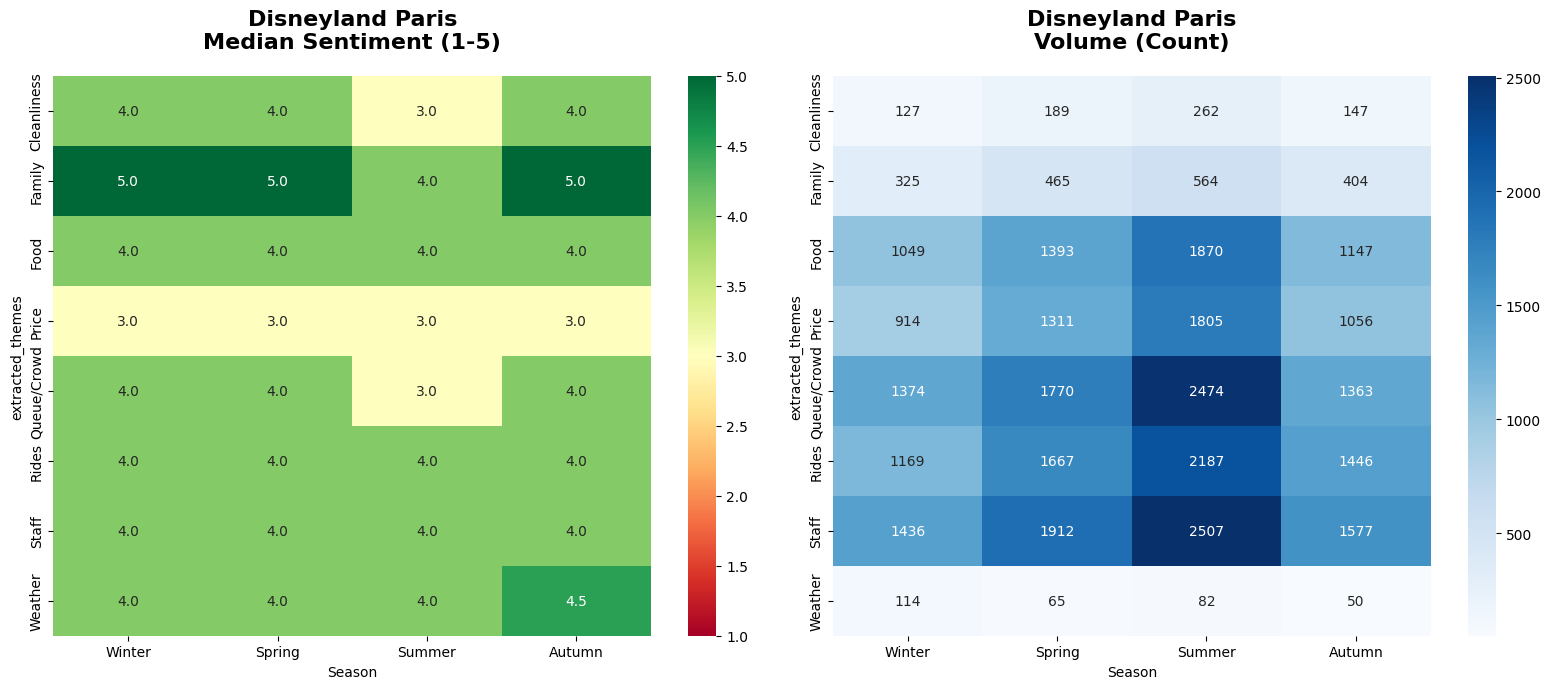

In [7]:
visualize_theme_sentiment(pd_disney)

### 2️⃣ What Drives Low Ratings?


=== Insight 2: What Drives Low Ratings? ===


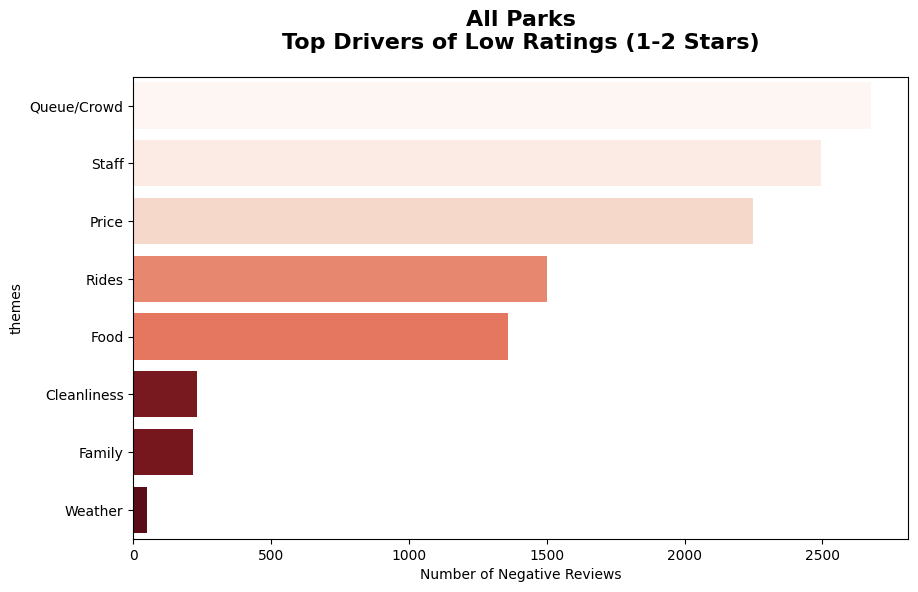

In [8]:
visualize_low_rating_drivers(pd_disney)

### 3️⃣ Seasonality Beyond Ratings


=== Insight 3: Seasonality Beyond Ratings ===


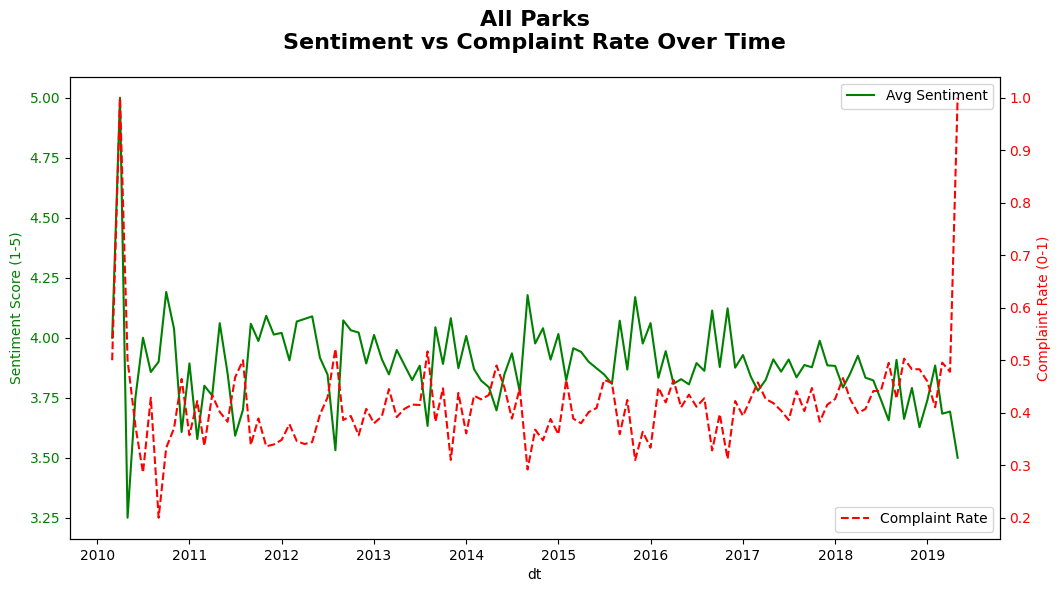

In [9]:
visualize_seasonality(pd_disney)

### 4️⃣ Country-Specific Expectations


=== Insight 4: Country-Specific Expectations ===


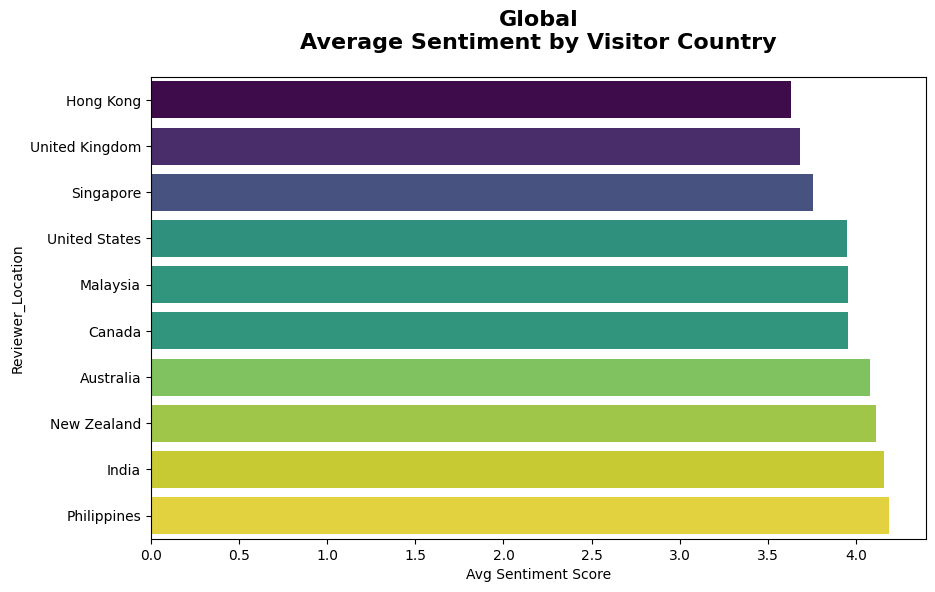

In [10]:
visualize_country_sentiment(pd_disney)

### 5️⃣ Staff Sentiment Deep Dive


=== Insight 5: Staff Sentiment Deep Dive ===


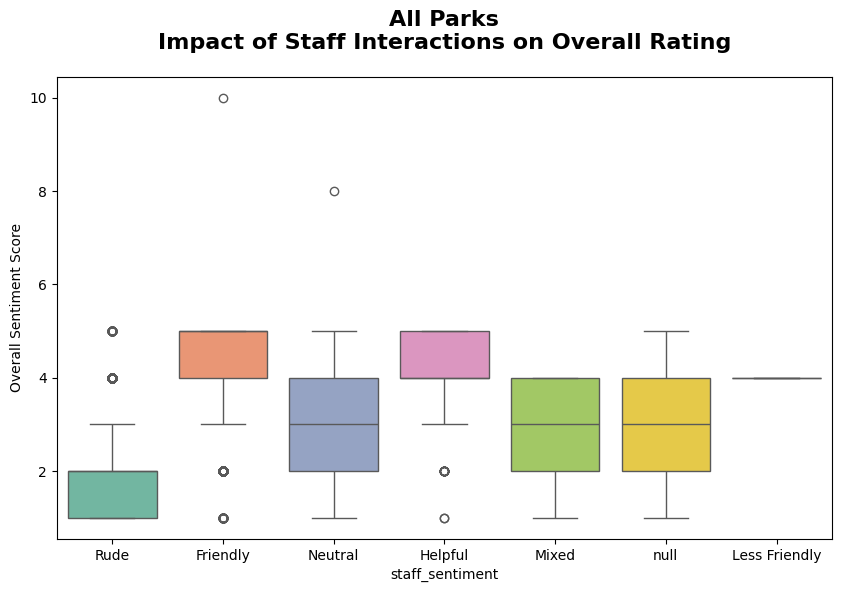

In [11]:
visualize_staff_impact(pd_disney)

### 6️⃣ Crowding Signal Validation


=== Insight 6: Crowding Signal Validation ===


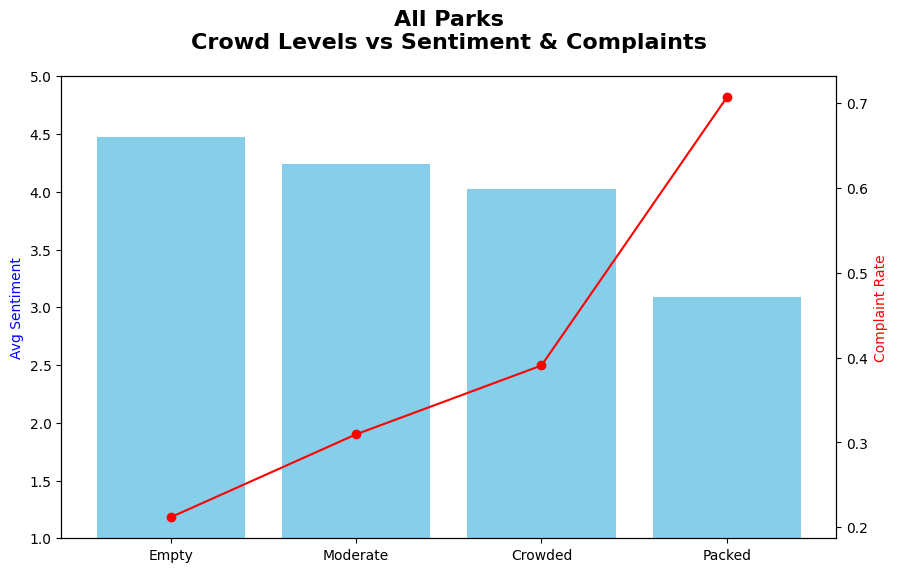

In [12]:
visualize_crowd_impact(pd_disney)

### 7️⃣ Evidence Quotes

In [13]:
# Example Usage: Filter for Packed crowds in California
get_evidence_quotes(pd_disney, filters={'crowd_level': 'Packed', 'Branch': 'Disneyland_California'}, n=3)


--- Evidence Quotes (Filters: {'crowd_level': 'Packed', 'Branch': 'Disneyland_California'}) ---
1. "Disneyland has been quite fun. We visited during spring bees which makes it quite busy, especially during the weekend. Staff are very good at moving people. The paint the night parade was awesome. The lineups were long and the food a little pricey, but all in all a great place to visit" (Rating: 4)
2. "I've been going to Disneyland since it opened..... I haven't been back in at least 12 years, (have been to Disney World in the past 6 years) There have been so many changes. I loved that a lot had been updated. I suggest you get there when it opens, we got there about 9 and got on seveeral big rides..." (Rating: 4)
3. "Highlights, Space mountain (always amazing) Pirates of the Caribbean (classic), Thunder Mountain (fun), Indiana Jones, Cool   painful, It's a small world (relaxing and classic), Haunted mansion (still magical). Not worth the price you pay. $155 for rides to be closed. Rip o

### 8️⃣ CX Playbook: Actionable Recommendations
Summary of critical issues prioritized by Volume and Severity.

In [14]:
# Generate and Display Playbook
playbook_df = generate_cx_playbook(pd_disney)
display_scrollable_dataframe(playbook_df, freeze_cols=3)


=== CX Playbook Generation ===


,park,issue,severity,trend,season,recommended_action,vol,evidence_metric,representative_quote
84,Paris,High Queue/Crowd friction,3.0,↑ Worse,Summer,"Increase staffing, capacity smoothing, promote early-entry",2474,34.1% negative,"Walt would not be happy with this version of Disneyland. People smoking everywhere, people rude, pushing in lines, cast members not interested at all in helping people cant say I felt any Disney Magic here...."
83,Paris,High Price friction,3.0,≈ Same,Summer,Improve value communication or bundle offerings,1805,40.2% negative,parents and I took 5 year old son. got on 3 rides. There for superheroes saw none. Extortionate prices
75,Paris,High Price friction,3.0,≈ Same,Spring,Improve value communication or bundle offerings,1311,37.5% negative,"Its the dream for kids but hard work. Food terrible worst ever. Micky's cafe a rip off Hotels OK but small rooms, transfers to park busy and lots of shoving around. Rides have long ques and in heat unbearably to do. P"
67,Paris,High Price friction,3.0,≈ Same,Autumn,Improve value communication or bundle offerings,1056,36.5% negative,"If you have already been to Disney, this is sure to disappoint. Only 4 thrill rides (one was closed). Park is very small we did everything in under 4 hours. If you do go, bring a lunch because food is crazy expensive and not good."
27,California,High Price friction,3.0,↑ Worse,Winter,Improve value communication or bundle offerings,955,35.3% negative,Surprised at how high the prices for everything is from the souvenirs to the food. We took our grandchildren and their parents . We had great accommodations at the Disneyland Hotel we had a suite which worked well with 6 of us . Over all very pricey not affordable for the average family .
91,Paris,High Price friction,3.0,≈ Same,Winter,Improve value communication or bundle offerings,914,39.1% negative,Too bloody expensive. 107 ticket for a day ticket. Queues of 2 hours for buzz lightyear. Other rides also more than an hour. Must be a french thing. No Disney figu
80,Paris,High Cleanliness friction,3.0,↑ Worse,Summer,Increase cleaning frequency during peak,262,40.8% negative,"So so overrated, what a load of crap. Hectic is an understatement and very very expensive to eat and drink their. Room was dirty would never go back we will stick to the Caribbean! My 3 year old hated it I did to."
21,California,High Rides friction,4.0,≈ Same,Summer,Proactive maintenance notification & queue management,2699,9.0% negative,"If you have been to Disney World this is a disappointment. Rides constantly were broke down, lines were"
86,Paris,High Staff friction,4.0,↓ Better,Summer,"Training on problem resolution, not politeness",2507,34.0% negative,"Walt would not be happy with this version of Disneyland. People smoking everywhere, people rude, pushing in lines, cast members not interested at all in helping people cant say I felt any Disney Magic here...."
20,California,High Queue/Crowd friction,4.0,↓ Better,Summer,"Increase staffing, capacity smoothing, promote early-entry",2491,19.4% negative,"Crowded too many people All the restaurants, rides was full with crazy lines Even the free rest chairs was full no where to sit Long line to have photo with characters Don t got in trap and buy fast pass tickets because even with fast pass you"


## Top 3 Priority Actions
**(Review the table above for specific interventions)**

In [ ]:
# --- Report Generation ---
if PRODUCE_PDF_REPORT:
    from stampli.reporting import generate_pdf_report, generate_excel_playbook
    
    # 1. Excel Playbook
    playbook_path = str(OUTPUT_DIR / "disney_cx_playbook.xlsx")
    # Assuming 'playbook_df' variable holds the result of generate_cx_playbook from previous cell
    # We need to make sure the previous cell assigns it. 
    # Let's verify if the CX Playbook cell assigns to a variable. 
    # If not, we might need to re-run generate_cx_playbook here or rely on the user modifying the notebook.
    # Safer approach: Call generate_cx_playbook again here to get the df, or check variable name.
    # In the current notebook state, the last cell usually just calls the function.
    # So let's re-generate it to be safe and ensuring we have the object.
    
    print("\n--- Generating Reports ---")
    playbook_df = generate_cx_playbook(pd_disney, save_dir=None)
    generate_excel_playbook(playbook_df, playbook_path)
    
    # 2. PDF Report
    # Using the plots directory we defined earlier
    plots_dir = str(OUTPUT_DIR)
    pdf_path = str(OUTPUT_DIR / "stampli_insights_report.pdf")
    generate_pdf_report(plots_dir, pdf_path)
    
    print(f"Reports ready:\n  - Excel: {playbook_path}\n  - PDF: {pdf_path}")
